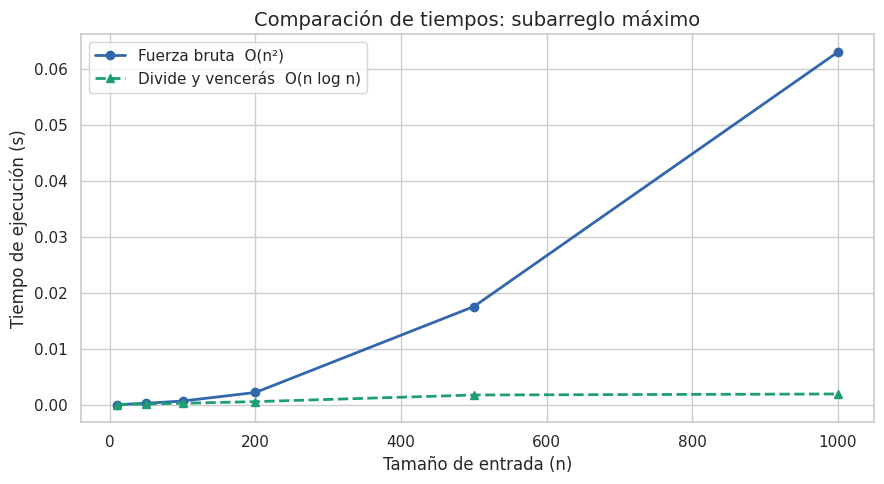


     n    Fuerza bruta (s)   Divide y vencerás (s)
----------------------------------------------------
    10            0.000011                0.000020
    50            0.000259                0.000123
   100            0.000652                0.000255
   200            0.002185                0.000544
   500            0.017539                0.001729
  1000            0.063026                0.001911


In [ ]:
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────
# 1. Algoritmo de fuerza bruta  O(n²)
# ─────────────────────────────────────────────
def max_subarray_brute(arr):
    n = len(arr)
    max_sum = float("-inf")
    best_low, best_high = 0, 0

    for i in range(n):
        current_sum = 0
        for j in range(i, n):
            current_sum += arr[j]
            if current_sum > max_sum:
                max_sum = current_sum
                best_low, best_high = i, j

    return best_low, best_high, max_sum


# ─────────────────────────────────────────────
# 2. Algoritmo divide y vencerás  O(n log n)
# ─────────────────────────────────────────────
def max_crossing_subarray(arr, low, mid, high):
    left_sum = float("-inf")
    suma = 0
    max_left = mid
    for i in range(mid, low - 1, -1):
        suma += arr[i]
        if suma > left_sum:
            left_sum = suma
            max_left = i

    right_sum = float("-inf")
    suma = 0
    max_right = mid + 1
    for j in range(mid + 1, high + 1):
        suma += arr[j]
        if suma > right_sum:
            right_sum = suma
            max_right = j

    return max_left, max_right, left_sum + right_sum


def max_subarray_dc(arr, low, high):
    if low == high:
        return low, high, arr[low]

    mid = (low + high) // 2
    left_low,  left_high,  left_sum  = max_subarray_dc(arr, low, mid)
    right_low, right_high, right_sum = max_subarray_dc(arr, mid + 1, high)
    cross_low, cross_high, cross_sum = max_crossing_subarray(arr, low, mid, high)

    if left_sum >= right_sum and left_sum >= cross_sum:
        return left_low, left_high, left_sum
    elif right_sum >= left_sum and right_sum >= cross_sum:
        return right_low, right_high, right_sum
    else:
        return cross_low, cross_high, cross_sum


# ─────────────────────────────────────────────
# 3. Medición de tiempos
# ─────────────────────────────────────────────
sizes = [10, 50, 100, 200, 500, 1000]
REPETITIONS = 5          # promedio sobre varias ejecuciones para estabilidad

brute_times = []
dc_times = []

for n in sizes:
    arr = [random.randint(-100, 100) for _ in range(n)]

    # Fuerza bruta
    t_start = time.perf_counter()
    for _ in range(REPETITIONS):
        max_subarray_brute(arr)
    brute_times.append((time.perf_counter() - t_start) / REPETITIONS)

    # Divide y vencerás
    t_start = time.perf_counter()
    for _ in range(REPETITIONS):
        max_subarray_dc(arr, 0, n - 1)
    dc_times.append((time.perf_counter() - t_start) / REPETITIONS)

# ─────────────────────────────────────────────
# 4. Gráfica comparativa
# ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(sizes, brute_times, marker="o", linewidth=2,
        label="Fuerza bruta  O(n²)", color="#3266ad")
ax.plot(sizes, dc_times,    marker="^", linewidth=2, linestyle="--",
        label="Divide y vencerás  O(n log n)", color="#1d9e75")

ax.set_xlabel("Tamaño de entrada (n)", fontsize=12)
ax.set_ylabel("Tiempo de ejecución (s)", fontsize=12)
ax.set_title("Comparación de tiempos: subarreglo máximo", fontsize=14)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))

plt.tight_layout()
plt.savefig("comparacion_tiempos.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 5. Resultados en consola
# ─────────────────────────────────────────────
print(f"\n{'n':>6}  {'Fuerza bruta (s)':>18}  {'Divide y vencerás (s)':>22}")
print("-" * 52)
for n, bt, dt in zip(sizes, brute_times, dc_times):
    print(f"{n:>6}  {bt:>18.6f}  {dt:>22.6f}")